# Современные методы анализа данных и машинного обучения, БИ

## НИУ ВШЭ, 2025-26 учебный год

## Проект №4. Statistics in Data Analysis


## Описание задания

Практика A/B-тестирования, формирования и проверки статистических гипотез лежит в основе принятия решений в любой современной компании, работающей с данными. Умение корректно провести эксперимент, проинтерпретировать результаты и сформулировать выводы непосредственно влияет на возможность роста продукта, сокращение издержек и уменьшение рисков.


Данный групповой проект состоит из **двух частей**:

1. **A/B-тестирование**: анализ результатов эксперимента, которые зафиксированы в датасете `data_ab.csv`, — проверка наличия статистически и практически значимых различий между наблюдениями в контрольной и экспериментальной группах.
2. **Проверка гипотез на выбранном датасете**: выбор одного или нескольких датасетов с сайта [UCI Machine Learning Repository](https://archive.ics.uci.edu/) либо же получение соответствующих датасетов путем парсинга/работы с API; осуществление этапа первичного анализа данных (EDA); определение не менее трёх содержательных гипотез **на основе проделанного EDA**; их проверка с помощью различнных статистических тестов.


### Постановка задачи

# Часть 1. A/B-тест

Для выполнения первой части группового проекта вам предоставляется датасет с результатами проведения некоторого A/B-тестирования в компании из сферы образования.


Датасет состоит из пяти столбцов:

* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).








По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`.

Вам следует:
- понять структуру данных, провести EDA и выбрать метрику, с которой будете работать;
- проверить корректность проведения тестирования (посмотреть на однородность групп; задуматься об A/A-тесте; не забыть, что в нашем распоряжении есть еще и временные метки);
- сформулировать нулевую и альтернативную гипотезы на основании выбранной метрики;
- выбрать и обосновать статистический тест;
- решить, нужно ли устаналивать значения каких-либо параметров до начала анализа тестирования;
- оценить разницу в результатах и сделать выводы о практической значимости эксперимента;
- провести дополнительный анализ при необходимости (например, с помощью [bootstrap](https://habr.com/ru/companies/X5Tech/articles/679842/)  или через анализ чувствительности);
- сформулировать рекомендации и бизнес-инсайты по результатам эксперимента.

**Важно**: это лишь возможные шаги для вашего исследования, и воспринимать их следует как подсказки. Ваша центральная задача в любом случае представлена в общем виде — осуществить качественный и полный анализ результатов проведенного A/B-тестирования.



## EDA: начало

In [ ]:
import pandas as pd

df = pd.read_csv('data_ab.csv')
print(df.shape)
df.head()

(294478, 5)


,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
df.duplicated().sum()

np.int64(0)

Нет полностью одинаковых строк

In [ ]:
df['user_id'].nunique()

290584

Есть дубликаты по **user_id**, их 3894 (1.32% от всего датасета)

In [ ]:
df['user_id'].value_counts()[df['user_id'].value_counts() > 1]

user_id
805339    2
754884    2
722274    2
783176    2
898232    2
         ..
847058    2
889392    2
664150    2
835401    2
736955    2
Name: count, Length: 3894, dtype: int64

In [ ]:
df['user_id'].value_counts()[df['user_id'].value_counts() > 2]

Series([], Name: count, dtype: int64)

Повторение user_id  максимум 2 раза

In [ ]:
dublicates = df[df['user_id'].duplicated(keep=False)].sort_values('user_id')
print(dublicates.shape)
dublicates.head(10)

(7788, 5)


,user_id,timestamp,group,landing_page,converted
230259,630052,2025-01-17 01:16:05.208766,treatment,new_page,0
213114,630052,2025-01-07 12:25:54.089486,treatment,old_page,1
22513,630126,2025-01-14 13:35:54.778695,treatment,old_page,0
251762,630126,2025-01-19 17:16:00.280440,treatment,new_page,0
183371,630137,2025-01-20 02:08:49.893878,control,old_page,0
11792,630137,2025-01-22 14:59:22.051308,control,new_page,0
207211,630320,2025-01-07 18:02:43.626318,control,old_page,0
255753,630320,2025-01-12 05:27:37.181803,treatment,old_page,0
96929,630471,2025-01-07 02:14:17.405726,control,new_page,0
110634,630471,2025-01-23 01:42:51.501851,control,old_page,0


In [ ]:
df[df.duplicated(subset=['user_id', 'timestamp'], keep=False)].shape[0]

0

то есть у нас нет строк дубликатов по паре user_id + timestamp

## Метрика

Возьмем за основную метрику
**conversion rate** = долю пользователей, совершивших целевое действие

Кроме основной метрики, будем в дальнейшем считать:
- абсолютную разницу конверсий (CRcontrol - CRtreatment)
- относительное изменение конверсий (CRcontrol - CRtreatment)/CRcontrol

In [ ]:
df.groupby(['group', 'landing_page'])['converted'].agg(['count', 'sum', 'mean'])

count    sum      mean
group     landing_page                         
control   new_page        1928    234  0.121369
          old_page      145274  17489  0.120386
treatment new_page      145311  17264  0.118807
          old_page        1965    250  0.127226

 Тест проведён не идеально чисто, потому что есть пользователи, у которых group не соответствует landing_page. По идее у control должна быть только old_page, а у treatment только new_page

 Так как у нас есть довольно мало признаков для того, чтобы понять как собирались группы, удалим строки которые не подходят по условию, так как это если оставить и отправить просто в другую группу неверные элементы, то это поменяет исходный экспериментальный дизайн, что недопустимо

## AA тест
Неправильные данные мы бы могли использовать для ААтеста нашего разделения групп, control old_page против treatment old_page, но это будет неправильно:
- это очень несбалансированные группы (145274 против 1965)
- treatment old_page - это не специально созданная A/A-ветка, а аномальные наблюдения
- такие строки могли появиться из-за бага, а не из-за нормальной рандомизации

То есть использовать control-old_page и treatment-old_page методологически неверно

В идеале A/A тест проводится до основного эксперимента на реальном трафике, но так как таких данных нет, воспользуемся симуляцией: возьмём только контрольную группу и многократно случайно разобьём её на две половины, каждый раз проводя z-тест(для конверсии тк это пропорциональная метрика и выборки достаточно большие)

Если рандомизация была честной, то:
- доля отвержений H0 должна быть близка к α = 0.05

In [ ]:
df_clean = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
].copy()

In [ ]:
df_clean.shape

(290585, 5)

In [ ]:
df_clean.groupby('group').agg(
    landing_page=('landing_page', 'first'),
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
)

,landing_page,users,conversions,conversion_rate
group,,,,
control,old_page,145274,17489,0.120386
treatment,new_page,145311,17264,0.118807


AA-тест для контроля:

In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

control = df_clean[df_clean['group'] == 'control']['converted'].values

np.random.seed(42)
p_values = []

for i in range (5000):
    mask = np.random.rand(len(control)) > 0.5
    part1, part2 = control[mask], control[~mask]
    z_stat, p_val = proportions_ztest([part1.sum(), part2.sum()], [len(part1), len(part2)])
    p_values.append(p_val)

print(f'Доля отвержений H0: {(np.array(p_values) < 0.05).mean():.3f}')

Доля отвержений H0: 0.055


AA-тест для тестовой группы:

In [ ]:
treatment = df_clean[df_clean['group'] == 'treatment']['converted'].values

np.random.seed(42)
p_values = []

for i in range (5000):
    mask = np.random.rand(len(treatment)) > 0.5
    part1, part2 = treatment[mask], treatment[~mask]
    z_stat, p_val = proportions_ztest([part1.sum(), part2.sum()], [len(part1), len(part2)])
    p_values.append(p_val)

print(f'Доля отвержений H0: {(np.array(p_values) < 0.05).mean():.3f}')

Доля отвержений H0: 0.047


Доля ложных отвержений H0 составила 5.5% (чуть выше 5%, но в пределах нормы) для контрольной и 4.7% для тестовой группы

Это подтверждает внутреннюю однородность групп и корректность рандомизации

Проверим группы внутри на дубли по user_id

In [ ]:
dublicates = df_clean[df_clean['user_id'].duplicated(keep=False)].sort_values('user_id')
print(dublicates.shape)
dublicates.head(10)

(2, 5)


,user_id,timestamp,group,landing_page,converted
1899,773192,2025-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2025-01-14 02:55:59.590927,treatment,new_page,0


Почти все дубликаты пропали (а именно 3894), то есть мы избавились от users которые попадали сразу в control, и в treatment. Это очень хорошо, так как в корректном A/B-тесте один и тот же пользователь обычно не должен одновременно попадать в обе группы, иначе нарушается независимость групп и интерпретация эффекта усложняется

In [ ]:
print(df_clean[df_clean['group'] == 'control']['user_id'].nunique())
print(df_clean[df_clean['group'] == 'treatment']['user_id'].nunique())

145274
145310


In [ ]:
print(df_clean[df_clean['group'] == 'control'].shape[0])
print(df_clean[df_clean['group'] == 'treatment'].shape[0])

145274
145311


In [ ]:
treatment_df = df_clean[df_clean['group'] == 'treatment']
treatment_df[treatment_df['user_id'].duplicated(keep=False)].sort_values('user_id')

,user_id,timestamp,group,landing_page,converted
1899,773192,2025-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2025-01-14 02:55:59.590927,treatment,new_page,0


In [ ]:
control_df = df_clean[df_clean['group'] == 'control']

## Проверка на временное распределение в группах

Сначала посмотрим на распределение трафика (по дням, по времени суток и по дням недели)

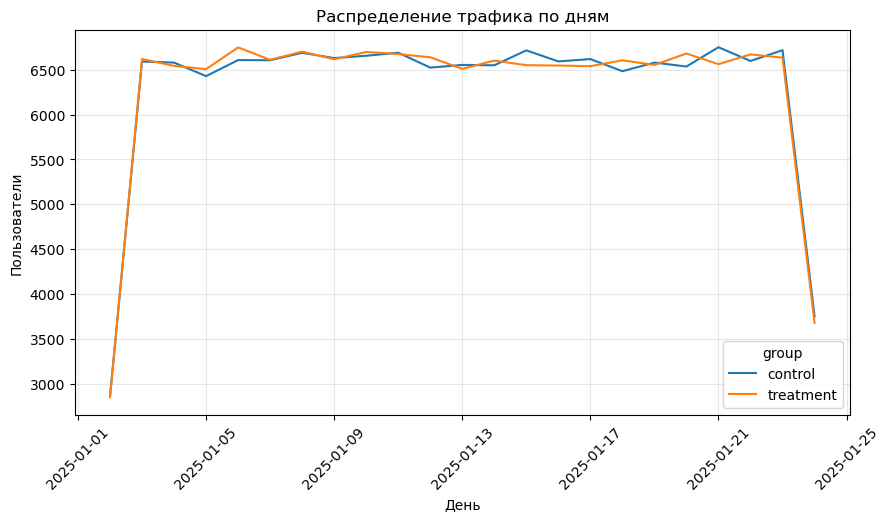

In [ ]:
import matplotlib.pyplot as plt

df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['date'] = df_clean['timestamp'].dt.date

daily_traffic = df_clean.groupby(['date', 'group']).size().unstack()

daily_traffic.plot(figsize=(10, 5))
plt.xlabel('День')
plt.ylabel('Пользователи')
plt.title('Распределение трафика по дням')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

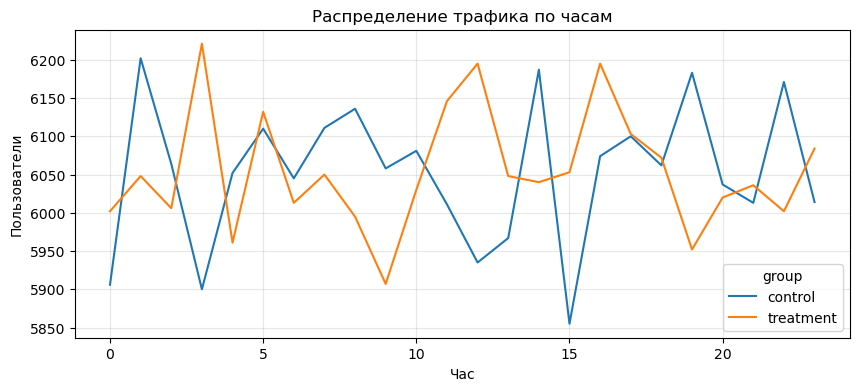

In [ ]:
df_clean['hour'] = df_clean['timestamp'].dt.hour

hourly = df_clean.groupby(['hour', 'group']).size().unstack()
hourly.plot(figsize=(10, 4))
plt.xlabel('Час')
plt.ylabel('Пользователи')
plt.title('Распределение трафика по часам')
plt.grid(True, alpha=0.3)
plt.show()

Распределение трафика в контрольной и тестовой группах равномерное и симметричное, явных временных перекосов нет

Трафик по дням недели

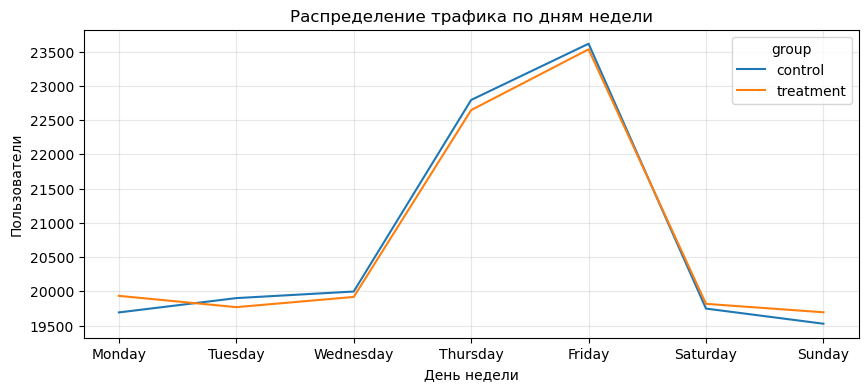

In [ ]:
df_clean['dayofweek'] = df_clean['timestamp'].dt.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly = df_clean.groupby(['dayofweek', 'group']).size().unstack().reindex(order)
weekly.plot(figsize=(10, 4))
plt.xlabel('День недели')
plt.ylabel('Пользователи')
plt.title('Распределение трафика по дням недели')
plt.grid(True, alpha=0.3)
plt.show()

Аналогично распределен равномерно

Из инсайтов: наибольший трафик приходится **на четверг и пятницу** (ожидаемо для образовательного сервиса), соотвественно минимальная длительнось тестов должна быть неделю (чтобы захватить пики)

Также эти дни можно рассмотреть с точки зрения отправки коммуникаций пользователям (пуши/email-ы и рассылки) для увеличения конверсии тк , пиковый трафик в эти дни означает что даже небольшой прирост конверсии через таргетированные коммуникации даст наибольший абсолютный эффект в числе регистраций

* Конверсия

Теперь интересно посмотреть как ведет себя конверсия в течении времени (по длням эксперимента)

Нет ли эффекта новизны в тестовой группе

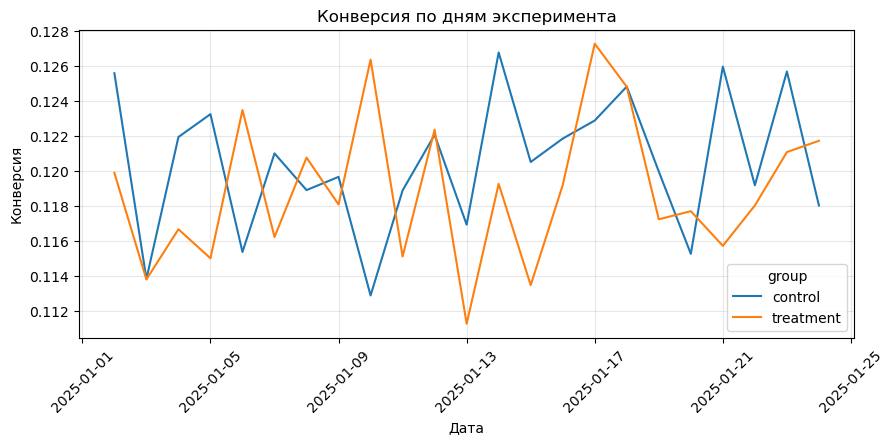

In [ ]:
df_clean['date'] = df_clean['timestamp'].dt.date

daily_cr = df_clean.groupby(['date', 'group'])['converted'].mean().unstack()

daily_cr.plot(figsize=(10, 4))
plt.xlabel('Дата')
plt.ylabel('Конверсия')
plt.title('Конверсия по дням эксперимента')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

##  SRM-проверка распределения 50/50 по дням

Учитывая что распределние групп: 145274 на 145311, можно на глаз сказать что группы +- равные, но сделаем SRM (Sample Ratio Mismatch) проверку **по дням эксперимента**

In [ ]:
from scipy.stats import chisquare

daily_counts = df_clean.groupby(['date', 'group']).size().unstack()

p_values = []
for date, row in daily_counts.iterrows():
    total = row['control'] + row['treatment']
    observed = [row['control'], row['treatment']]
    expected = [total / 2, total / 2]
    chi, p = chisquare(observed, f_exp=expected)
    p_values.append({'date': date, 'p_value': p})

srm_df = pd.DataFrame(p_values)

print(f'Дней с SRM (p < 0.05): {(srm_df["p_value"] < 0.05).sum()} из {len(srm_df)}')

Дней с SRM (p < 0.05): 0 из 23


## Накопительная конверсия по дням

Для полной картины накопительная конверсия в обеих группах

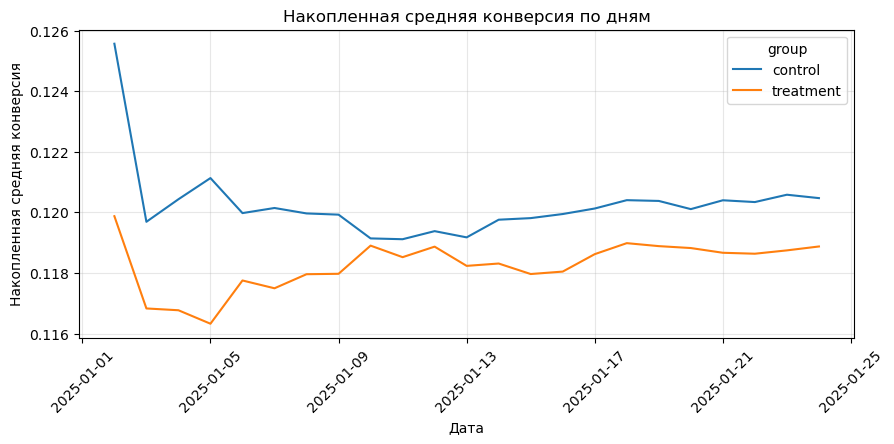

In [ ]:
df_clean_sorted = df_clean.sort_values('date')

cumulative = df_clean_sorted.groupby(['date', 'group'])['converted'].mean().unstack()
cumulative_mean = cumulative.expanding().mean()

cumulative_mean.plot(figsize=(10, 4))
plt.xlabel('Дата')
plt.ylabel('Накопленная средняя конверсия')
plt.title('Накопленная средняя конверсия по дням')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

Накопленная конверсия обеих групп стабилизируется примерно к 8-10 января, после этого оценки практически не меняются

Это значит, что эксперимент можно было останавливать уже через неделю, данных было достаточно -> потенциально дизайн эксперимента нужно доработать

Разрыв между группами стабильный: control всегда чуть выше treatment, но линии параллельны и не сближаются

## Гипотезы

- H0: новая версия лендинга не меняет конверсию по сравнению со старой

- H1: новая версия лендинга приводит к изменению конверсии


## z-тест

Для сравнения конверсий контрольной и экспериментальной групп используется z-тест для двух долей, так как конверсия является бинарной метрикой, а объёмы выборок достаточно велики.

## Почему не t-test
t-test обычно применяют для сравнения средних непрерывных величин, а здесь исход бинарный. Формально среднее бинарной переменной равно доле конверсий, но для A/B-задачи с конверсией более естественным и интерпретируемым является именно тест на разницу пропорций.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

successes = [treatment['converted'].sum(), control['converted'].sum()]
nobs = [treatment['converted'].count(), control['converted'].count()]

z_stat, p_value = proportions_ztest(successes, nobs, alternative='two-sided')

print(f'z-статистика: {round(z_stat, 3)}')
print(f'p-value: {round(p_value, 3)}')
print(f'Вывод: {"отвергаем H0" if p_value < 0.05 else "не отвергаем H0"} (alpha = 0.05)')

z-статистика: -1.312
p-value: 0.19
Вывод: не отвергаем H0 (alpha=0.05)


По результатам z-теста для сравнения двух долей получено значение статистики z=-1.31 и p-value=0.1897. Поскольку p-value>0.05, оснований отвергнуть нулевую гипотезу нет. Следовательно, статистически значимых различий в конверсии между контрольной и экспериментальной группами не выявлено.

Отрицательный знак статистики указывает на то, что конверсия экспериментальной группы ниже конверсии контрольной, однако данное различие не является статистически значимым.

In [ ]:
cr_control = control['converted'].mean()
cr_treatment = treatment['converted'].mean()

abs_diff = cr_treatment - cr_control
rel_diff = abs_diff / cr_control

print(f"Конверсия control: {round(cr_control * 100, 2)}%")
print(f"Конверсия treatment: {round(cr_treatment * 100, 2)}%")
print(f"Абсолютная разница: {round(abs_diff * 100, 2)}%")
print(f"Относительная разница: {round(rel_diff * 100, 2)}%")

Конверсия control: 12.04%
Конверсия treatment: 11.88%
Абсолютная разница: -0.16%
Относительная разница: -1.31%


Новая версия лендинга не показала статистически значимого улучшения конверсии, поэтому оснований считать её лучше текущей нет и на текущих данных не может быть рекомендована к внедрению как более эффективная

Экспериментальная группа показала слегка более низкую конверсию, но это различие можно объяснить случайными колебаниями

## Если эффект есть, смог бы тест его обнаружить?

Посчитаем мощность теста - вероятность обнаружить эффект если он реально существует, для разных значений MDE (минимального детектируемого эффекта)

Это покажет насколько тест был чувствителен к разным уровням улучшения конверсии

In [ ]:
from scipy.stats import norm

base_cr = df_clean[df_clean['group'] == 'control']['converted'].mean()
n = len(df_clean[df_clean['group'] == 'control'])

def get_power(cr1, cr2, n, alpha=0.05):
    p = (cr1 + cr2) / 2
    se = (2 * p * (1 - p) / n) ** 0.5 # cтандартная ошибка разницы пропорций (мера того, насколько сильно выборочная оценка может отклоняться от истинного значения из-за случайности)
    z_alpha = norm.ppf(1 - alpha / 2)
    z = abs(cr2 - cr1) / se - z_alpha
    return norm.cdf(z)

for mde in [0.01, 0.0131, 0.02, 0.03, 0.05]:
    power = get_power(base_cr, base_cr * (1 + mde), n)
    print(f'MDE = {round((mde*100), 2)}% Мощность: {round(power, 3)}')

MDE = 1.0% Мощность: 0.167
MDE = 1.31% Мощность: 0.255
MDE = 2.0% Мощность: 0.51
MDE = 3.0% Мощность: 0.844
MDE = 5.0% Мощность: 0.999


Это довольно важные показатели для интерпретации теста тк по модулю относительная разница в конверсиях получилась 1.31% — и именно при таком MDE мощность теста равна всего 25.5%. Это означает что даже если эффект реально существует, наш тест обнаружил бы его лишь в каждом четвёртом случае. Для достижения стандартной мощности 80% необходим эффект не менее 3% — то есть наблюдаемая разница была слишком мала для надёжного обнаружения при данном размере выборки

Это подтверждение того что отсутствие значимого результата не означает отсутствие эффекта — тест просто не обладал достаточной чувствительностью

In [ ]:
def get_n(cr1, cr2, alpha=0.05, power=0.8):
    p = (cr1 + cr2) / 2
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    return 2 * p * (1 - p) * ((z_alpha + z_beta) / abs(cr2 - cr1)) ** 2

daily_users = len(df_clean) / 23    #тест длился 23 дня, смотрим трафик в день

print('Необходимый размер выборки (на группу):')
for mde_rel in [0.01, 0.0131, 0.02, 0.03, 0.05]:
    cr2 = base_cr * (1 + mde_rel)
    n = get_n(base_cr, cr2)
    days = (n * 2) / daily_users
    print(f'MDE = {round(mde_rel*100, 2)}%;  n = {int(n)} на группу; Длительность: {round(days)} дней')

Необходимый размер выборки (на группу):
MDE = 1.0%;  n = 1151917 на группу; Длительность: 182 дней
MDE = 1.31%;  n = 672133 на группу; Длительность: 106 дней
MDE = 2.0%;  n = 289213 на группу; Длительность: 46 дней
MDE = 3.0%;  n = 129087 на группу; Длительность: 20 дней
MDE = 5.0%;  n = 46864 на группу; Длительность: 7 дней


Для обнаружения фактической относительной разницы в 1.31% с мощностью 80% потребовалось бы 672тыс. пользователей на группу и 106 дней

Это объясняет почему тест не дал значимого результата: выборки просто не хватило для детектирования столь малого эффекта

Для практически значимого улучшения в 5% хватило бы 7 дней и 47тыс. пользователей на группу. Это и есть рекомендуемый ориентир для дизайна следующего эксперимента: заранее определить минимальный бизнес-значимый эффект и под него рассчитать выборку

## Параметры
- Уровень значимости α=0.05
- Мощность теста β=0.8 — вероятность обнаружить эффект если он существует
- Двусторонняя альтернатива — так как направление эффекта заранее неизвестно
- Дополнительно проверяется односторонняя гипотеза H1: новая страница улучшает конверсию
- MDE задаётся относительно базовой конверсии контрольной группы
- Размер выборки рассчитывается исходя из alpha, beta и MDE — а не произвольно
- Анализ проводится на очищенных данных: удалены строки с несоответствием group и landing_page

##Bootstrap
Bootstrap - это метод переcэмплирования: из имеющихся данных много раз случайно выбирают наблюдения с возвращением, каждый раз пересчитывают нужную статистику, а потом по полученному распределению оценивают разброс эффекта и доверительный интервал.

In [ ]:
control_conv = df_clean[df_clean['group'] == 'control']['converted'].values
treatment_conv = df_clean[df_clean['group'] == 'treatment']['converted'].values

np.random.seed(42)
boot_diffs = []

for _ in range(5000):
    c = control_conv[np.random.randint(0, len(control_conv), len(control_conv))]
    t = treatment_conv[np.random.randint(0, len(treatment_conv), len(treatment_conv))]
    boot_diffs.append(t.mean() - c.mean())

ci_low  = round(np.percentile(boot_diffs, 2.5), 5)
ci_high = round(np.percentile(boot_diffs, 97.5), 5)

print(f'Среднее: {round(np.mean(boot_diffs), 5)}')
print(f'95% ДИ: [{ci_low}, {ci_high}]')

Среднее: -0.00159
95% ДИ: [-0.00394, 0.00073]


По результатам bootstrap 95% доверительный интервал для разницы конверсий между экспериментальной и контрольной группами составил
 [−0.00394; 0.00073]. Поскольку интервал включает 0, статистически значимых различий между группами не выявлено. Результат bootstrap согласуется с выводом, полученным ранее с помощью z-теста.

## анализ чувствительности

In [ ]:
print('Чувствительность к уровню значимости:')
for alpha in [0.01, 0.05, 0.1, 0.2]:
    z_stat, p = proportions_ztest(
        [treatment['converted'].sum(), control['converted'].sum()],
        [len(treatment), len(control)]
    )
    res = 'отвергаем H0' if p < alpha else 'не отвергаем H0'
    print(f'alpha = {alpha}: {res}')

print('\nЧувствительность к размеру выборки:')
for mult in [1, 2, 5, 10, 20]:
    n = int(len(control) * mult)
    power = get_power(base_cr, base_cr * (1 + 0.0131), n)
    print(f'n = {int(n)} (уножили на {mult})  мощность: {round(power, 3)}')

Чувствительность к уровню значимости:
alpha = 0.01: не отвергаем H0
alpha = 0.05: не отвергаем H0
alpha = 0.1: не отвергаем H0
alpha = 0.2: отвергаем H0

Чувствительность к размеру выборки:
n = 145274 (уножили на 1)  мощность: 0.255
n = 290548 (уножили на 2)  мощность: 0.453
n = 726370 (уножили на 5)  мощность: 0.83
n = 1452740 (уножили на 10)  мощность: 0.985
n = 2905480 (уножили на 20)  мощность: 1.0


Вывод устойчив при любом разумном уровне значимости вплоть до alpha = 0.1 — H0 отвергается только при alpha = 0.2, что слишком строго

По размеру выборки: для обнаружения фактической разницы в 1.31% с мощностью 80% потребовалось бы примерно 726тыс пользователей на группу. При текущем n = 145тыс мощность составляет лишь 25.5% (частично ранее уже затрагивалось)

## Бизнес-инсайты и выводы

- В данных обнаружены нарушения соответствия между назначенной группой и фактически показанной страницей, поэтому перед следующими тестами стоит проверить логику эксперимента и качество трекинга

- Новая версия лендинга не дала статистически значимого роста регистраций, поэтому оснований для её внедрения на весь трафик сейчас нет

- Накопленная конверсия стабилизируется уже через 7-10 дней после старта. Для следующего теста рекомендуется заранее зафиксировать MDE на уровне 3-5%, рассчитать под него выборку (130-47тыс. пользователей на группу соответственно) и не останавливать тест раньше достижения нужного объёма

- Трафик имеет выраженный недельный паттерн с пиком в четверг-пятницу. Минимальная длительность следующего теста должна быть кратна полной неделе. Кроме того, высокий трафик в пятницу означает что даже небольшой прирост конверсии через таргетированные коммуникации (email, пуш) даст наибольший абсолютный эффект в числе регистраций — это гипотеза для отдельного эксперимента

- Перед запуском следующего теста рекомендуется провести оценку экономической целесообразности: рассчитать ожидаемый прирост выручки от гипотетического улучшения конверсии и сравнить его со стоимостью разработки изменения. Если ожидаемый эффект меньше порога окупаемости — тест нецелесообразен вне зависимости от статистической значимости

# Часть 2. A/B-тест Демографические данные США

## Датасет: Adult Census Income
Источник: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult)  
Данные переписи работающего населения США — около 48 тыс. записей о людях с социально-демографическими характеристиками и бинарной меткой дохода (>50K / ≤50K в год)  
**Прикладной контекст:** результаты анализа могут быть использованы HR-аналитиками, страховыми компаниями и кредитными организациями для понимания факторов, ассоциированных с уровнем дохода

## 1. Загрузка и предобработка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg
from scipy.stats import shapiro, levene, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df_raw = pd.read_csv('./adult/adult.data', names=columns, na_values=' ?')
df_raw.drop(columns=['fnlwgt', 'education_num'], inplace=True)

In [ ]:
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].str.strip()

In [ ]:
df_raw.shape

(32561, 13)

In [ ]:
df_raw.head()

,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df_raw.isna().sum()

age                  0
workclass         1836
education            0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [ ]:
df = df_raw.dropna().copy()
df.shape

(30162, 13)

## 2. Разведочный анализ данных (EDA)

### 2.1 Описательные статистики числовых признаков

In [ ]:
numeric_cols = ['age', 'capital_gain', 'capital_loss', 'hours_per_week']

desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['median'] = df[numeric_cols].median()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,median
age,30162.0,38.44,13.13,17.0,28.0,37.0,47.0,90.0,0.53,37.0
capital_gain,30162.0,1092.01,7406.35,0.0,0.0,0.0,0.0,99999.0,11.90,0.0
capital_loss,30162.0,88.37,404.30,0.0,0.0,0.0,0.0,4356.0,4.53,0.0
hours_per_week,30162.0,40.93,11.98,1.0,40.0,40.0,45.0,99.0,0.33,40.0


### 2.2 Целевая переменная и числовые признаки по группам дохода

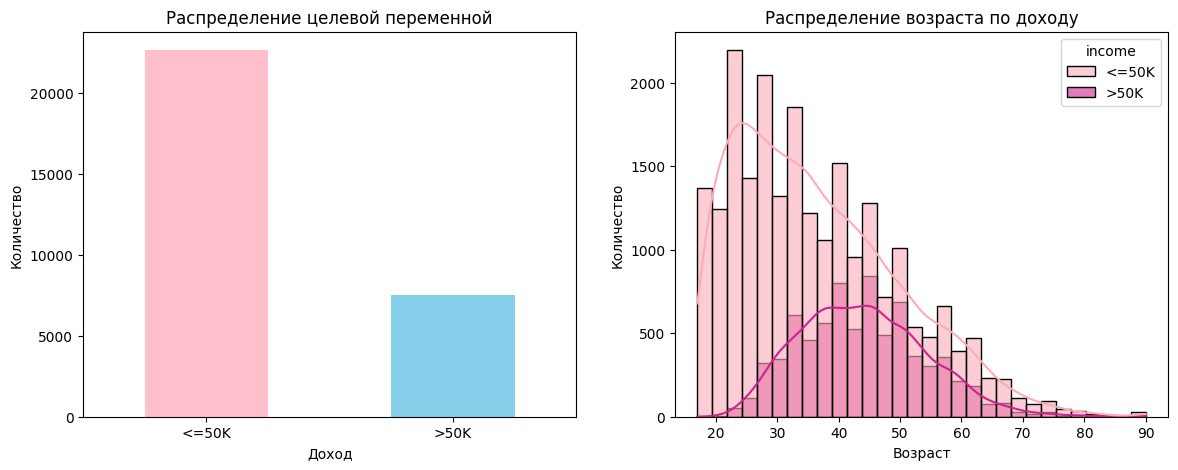

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors= ['pink', 'skyblue']
df['income'].value_counts().plot(kind='bar',ax=axes[0],color=colors)
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('Доход')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(data=df,x='age',hue='income',kde=True,bins=30,ax=axes[1],alpha=0.6, palette='RdPu')
axes[1].set_title('Распределение возраста по доходу')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Количество')

plt.show()

Датасет несбалансирован: ~76% людей зарабатывают <=50K, видим, что их распределение менее похоже на нормальное, чем >50K

### 2.3 Пол, образование и доход

In [ ]:
df_raw['sex'].value_counts()

sex
Male      21790
Female    10771
Name: count, dtype: int64

In [ ]:
edu_order = ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th',
             'HS-grad','Some-college','Assoc-voc','Assoc-acdm','Bachelors',
             'Masters','Prof-school','Doctorate']
df['income_bin'] = (df['income'] == '>50K').astype(int)

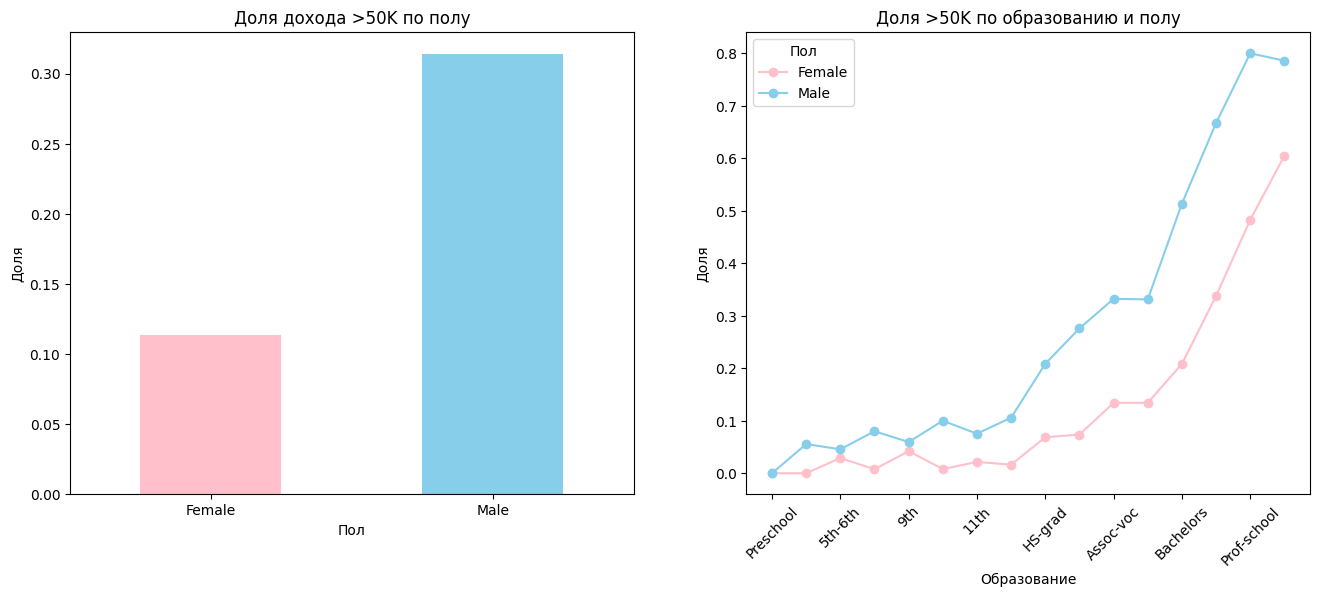

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sex_income = df.groupby('sex')['income_bin'].mean()
sex_income.plot(kind='bar',ax=axes[0],color=colors)
axes[0].set_title('Доля дохода >50K по полу')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Доля')
axes[0].tick_params(axis='x', rotation=0)

edu_sex = (df.groupby(['education', 'sex'])['income_bin'].mean().unstack().loc[edu_order])
edu_sex.plot(kind='line',marker='o',ax=axes[1],color=colors)
axes[1].set_title('Доля >50K по образованию и полу')
axes[1].set_xlabel('Образование')
axes[1].set_ylabel('Доля')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Пол')

plt.show()

Мужчины зарабатывают >50K примерно в 3 раза чаще, чем женщины, на втором графике видно, что разрыв сохраняется на всех уровнях образования, но особенно заметен начиная с Bachelors. Это наводит на гипотезу: высшее образование не устраняет гендерный разрыв полностью

### 2.4 Вид занятости и доход

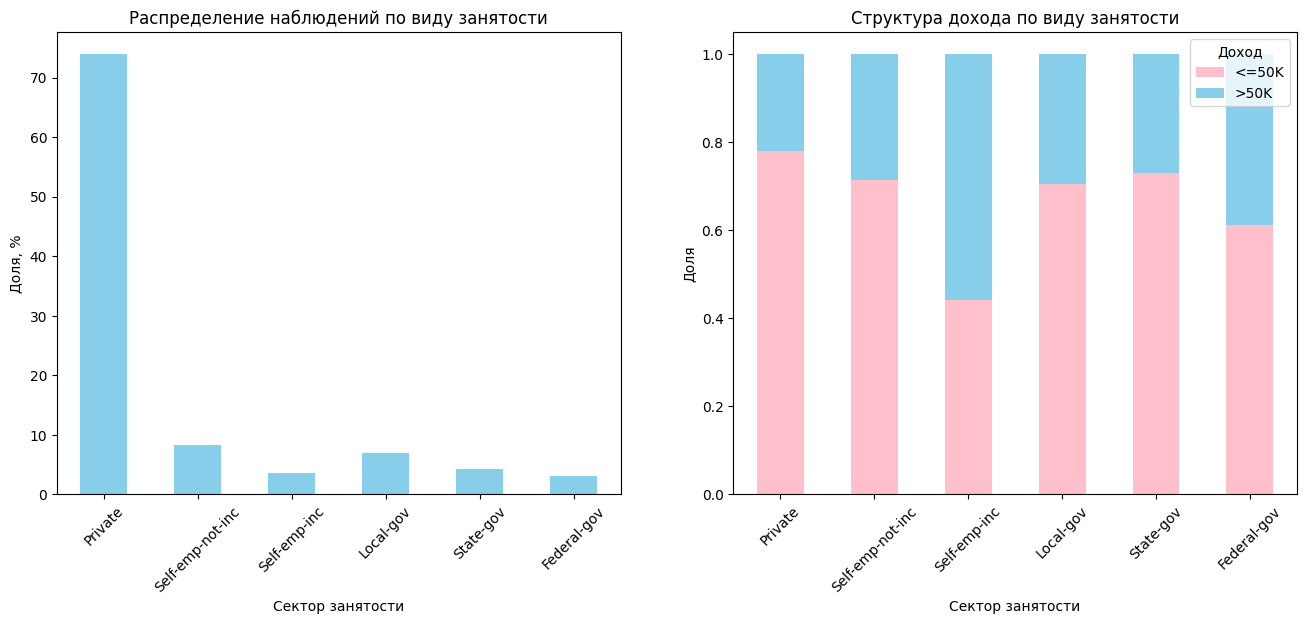

In [ ]:
sectors = ['Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Local-gov', 'State-gov', 'Federal-gov']
df_sec = df[df['workclass'].isin(sectors)].copy()
df_sec['income'] = df_sec['income'].str.strip()

sector_pct = df_sec['workclass'].value_counts(normalize=True).reindex(sectors) * 100
ct = pd.crosstab(df_sec['workclass'], df_sec['income'], normalize='index')
ct = ct.loc[sectors, ['<=50K', '>50K']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sector_pct.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Распределение наблюдений по виду занятости')
axes[0].set_xlabel('Сектор занятости')
axes[0].set_ylabel('Доля, %')
axes[0].tick_params(axis='x', rotation=45)

ct.plot(kind='bar', stacked=True, ax=axes[1],color=colors)
axes[1].set_title('Структура дохода по виду занятости')
axes[1].set_xlabel('Сектор занятости')
axes[1].set_ylabel('Доля')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Доход')

plt.show()

- самозанятые с зарегистрированной компанией - лидеры по доле >50K (~56%)  
- Разброс долей между секторами большой - это наводит на гипотезу о неоднородности распределения дохода по секторам

### 2.5 Доход в зависимости от семейного статуса

In [ ]:
pd.crosstab(df['sex'], df['marital_status'])

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
sex,,,,,,,
Female,2529,12,1480,189,4312,574,686
Male,1685,9,12585,181,5414,365,141


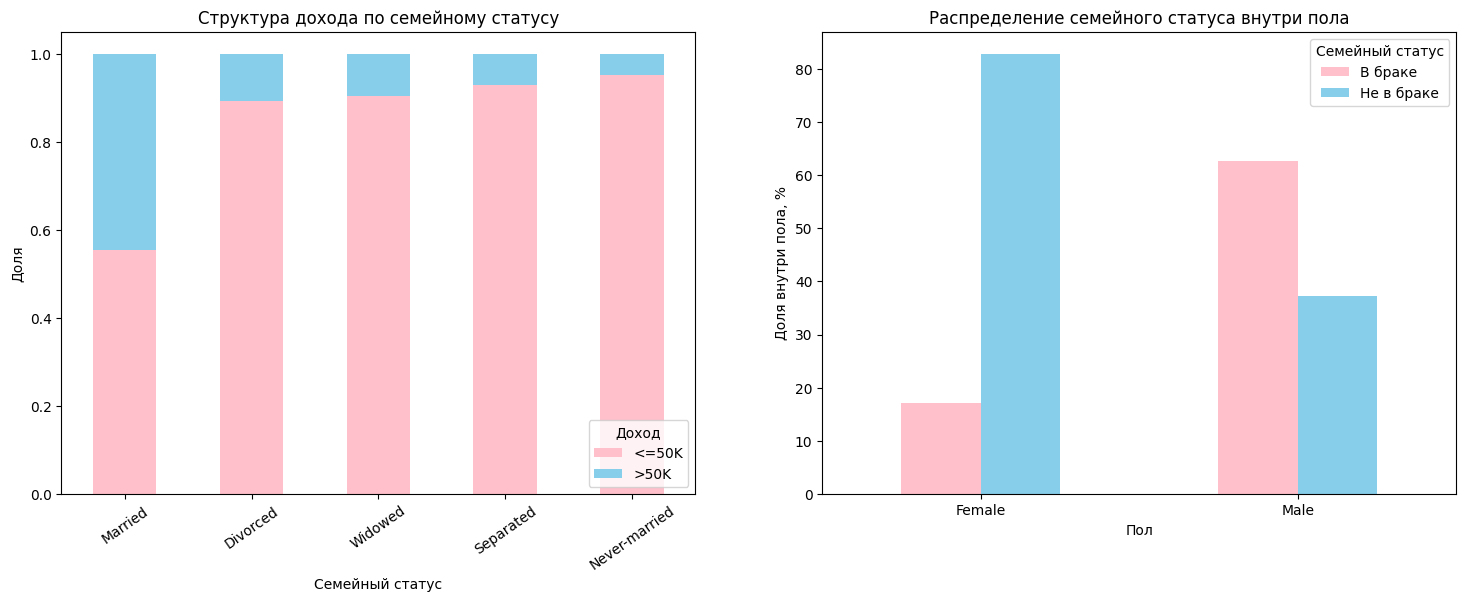

In [ ]:
df['marital_group'] = df['marital_status'].replace({
    'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'Married'})

df['married_group'] = np.where(df['marital_group'] == 'Married', 'В браке', 'Не в браке')
ct_marital = pd.crosstab(df['marital_group'],df['income'],normalize='index')[['<=50K', '>50K']]
ct_marital = ct_marital.sort_values('>50K', ascending=False)

sex_married_pct = pd.crosstab(df['sex'],df['married_group'],normalize='index')[['В браке', 'Не в браке']] * 100
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ct_marital.plot(kind='bar',stacked=True,ax=axes[0],color=colors)
axes[0].set_title('Структура дохода по семейному статусу')
axes[0].set_xlabel('Семейный статус')
axes[0].set_ylabel('Доля')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Доход', loc='lower right')

sex_married_pct.plot(kind='bar',ax=axes[1],color=colors)
axes[1].set_title('Распределение семейного статуса внутри пола')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Доля внутри пола, %')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Семейный статус')

plt.show()

In [ ]:
pd.crosstab(df['sex'], df['married_group'])

married_group,В браке,Не в браке
sex,,
Female,1681,8101
Male,12775,7605


Семейный статус связан с уровнем дохода: самые высокие доли дохода >50K наблюдаются у людей в браке, особенно в категории Married. У категорий Never-married, Separated, Widowed и Divorced доля дохода >50K заметно ниже

При разбиении по полу видно, что и у мужчин, и у женщин брак связан с более высокой долей дохода >50K. Среди людей не в браке доля высокого дохода остаётся низкой, особенно у женщин

*P.S. Объединли категории Married-AF-spouse и Married-civ-spouse в одну общую Married, тк они маленькие для отдельного изучения*

### 2.6 Рабочие часы и доход

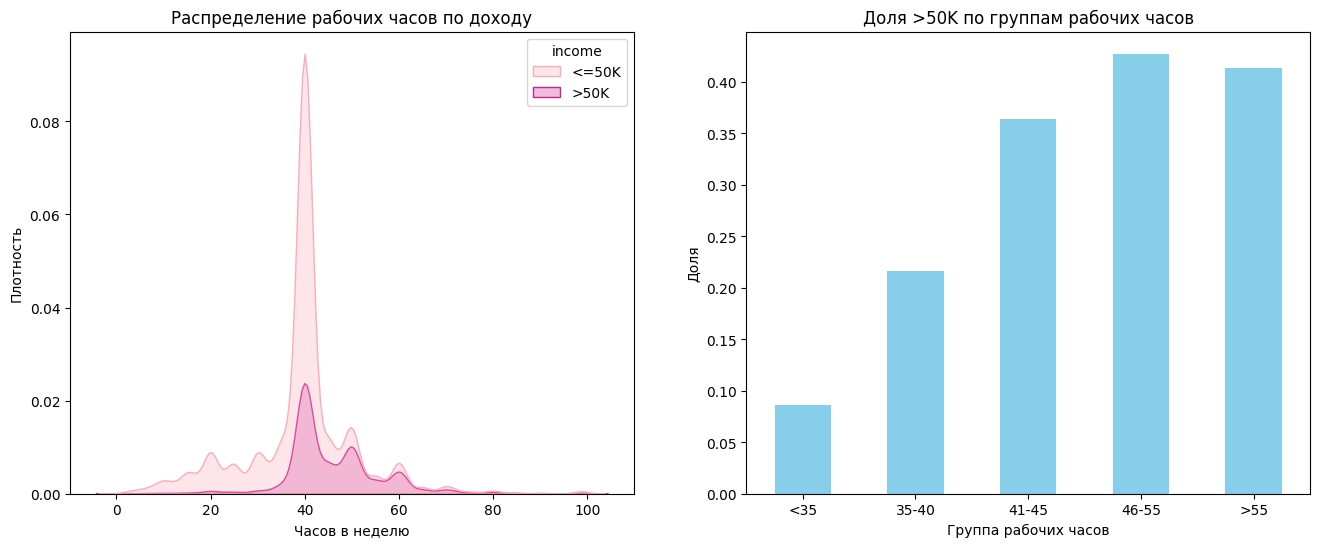

In [ ]:
df['hours_group'] = pd.cut(df['hours_per_week'],bins=[0, 35, 40, 45, 55, 99],labels=['<35', '35-40', '41-45', '46-55', '>55'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(data=df,x='hours_per_week',hue='income',fill=True,alpha=0.3,ax=axes[0], palette='RdPu')
axes[0].set_title('Распределение рабочих часов по доходу')
axes[0].set_xlabel('Часов в неделю')
axes[0].set_ylabel('Плотность')

hg = df.groupby('hours_group', observed=True)['income_bin'].mean()
hg.plot(kind='bar',ax=axes[1], color='skyblue')
axes[1].set_title('Доля >50K по группам рабочих часов')
axes[1].set_xlabel('Группа рабочих часов')
axes[1].set_ylabel('Доля')
axes[1].tick_params(axis='x', rotation=0)

plt.show()

- Медиана рабочих часов у группы >50K выше (45 ч против 40 ч)  
- С ростом рабочих часов доля >50K монотонно растёт - выраженный паттерн

### 2.7 Capital gain

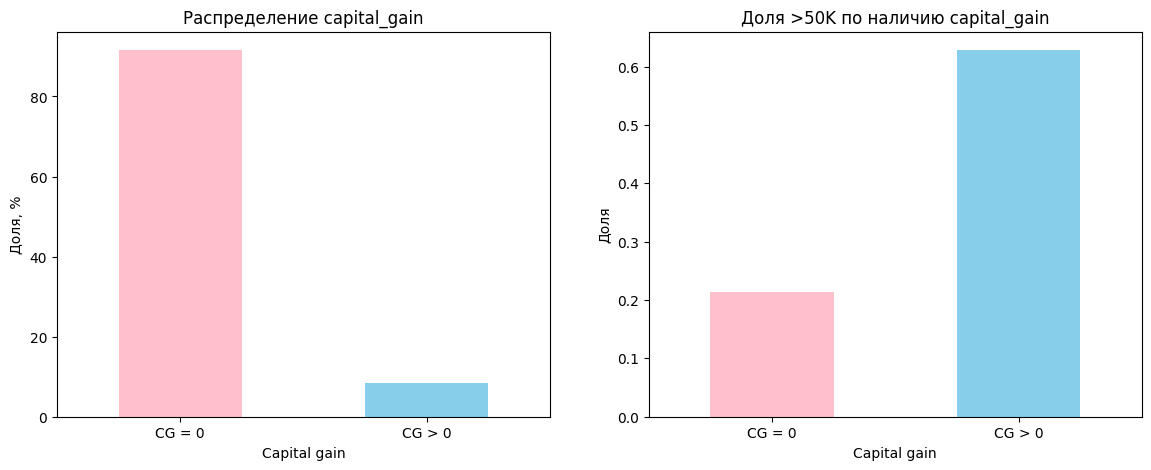

In [ ]:
df['cg_group'] = np.where(df['capital_gain'] > 0, 'CG > 0', 'CG = 0')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cg_dist = df['cg_group'].value_counts(normalize=True) * 100
cg_dist.plot(kind='bar',ax=axes[0],color=colors)
axes[0].set_title('Распределение capital_gain')
axes[0].set_xlabel('Capital gain')
axes[0].set_ylabel('Доля, %')
axes[0].tick_params(axis='x', rotation=0)

inc_by_cg = df.groupby('cg_group')['income_bin'].mean()
inc_by_cg.plot(kind='bar',ax=axes[1],color=colors)
axes[1].set_title('Доля >50K по наличию capital_gain')
axes[1].set_xlabel('Capital gain')
axes[1].set_ylabel('Доля')
axes[1].tick_params(axis='x', rotation=0)

plt.show()

- 91.7% людей имеют capital_gain = 0
- Среди тех, у кого capital_gain > 0, доля >50K в разы выше (~73% против ~22%)  
Наличие инвестиционного дохода фактически разделяет датасет на два разных сегмента

### 2.8 Возраст достижения >50K по уровню образования

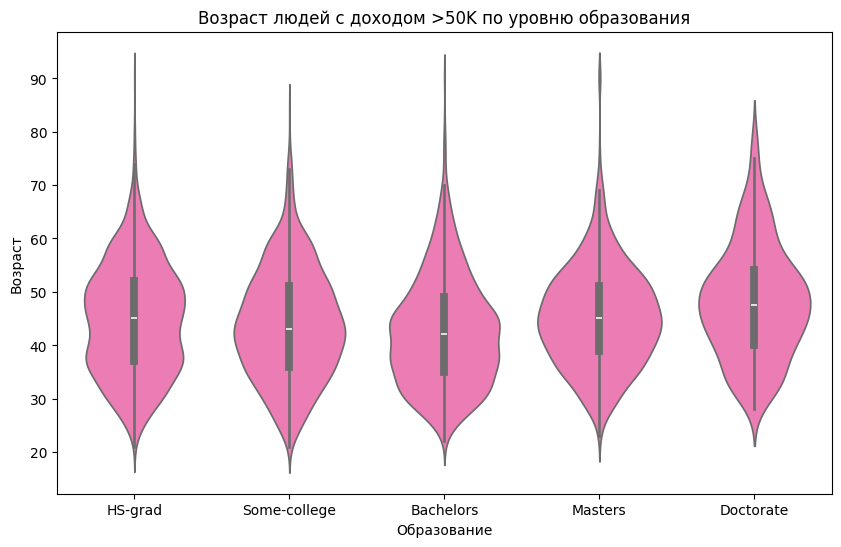

In [ ]:
edu_5 = ['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Doctorate']
df_rich = df[(df['income'] == '>50K') &(df['education'].isin(edu_5))]

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_rich,x='education',y='age',order=edu_5, ax=ax, color='hotpink')
ax.set_title('Возраст людей с доходом >50K по уровню образования')
ax.set_xlabel('Образование')
ax.set_ylabel('Возраст')
ax.tick_params(axis='x')

plt.show()

In [ ]:
df_rich.groupby('education')['age'].median().loc[edu_5]

education
HS-grad         45.0
Some-college    43.0
Bachelors       42.0
Masters         45.0
Doctorate       47.5
Name: age, dtype: float64

- Выраженный паттерн: чем выше образование, тем позже человек начинает зарабатывать >50K — Doctorate сдвинут вверх  
- HS-grad, если и достигает >50K, делает это за счёт стажа, в среднем позже, чем Bachelors  
- Распределения явно не нормальны и различаются по форме — нужен непараметрический критерий

## 3. Проверка данных перед статтестами

У нас очень большой датасет (48к строк), поэтому делать тест Шапиро-Уилка на нормальность нет смысла, так как он покажет что данные не нормальны почти всегда — он очень чувствителен к даже небольшим отклонениям. Будем использовать QQ plots и ЦПТ

In [ ]:
from scipy.stats import probplot

In [ ]:
group_high = df[df['income'] == '>50K']['hours_per_week']
group_low = df[df['income'] == '<=50K']['hours_per_week']
cg0_hours = df[df['capital_gain'] == 0]['hours_per_week']
cg1_hours = df[df['capital_gain'] > 0]['hours_per_week']

In [ ]:
edu_5 = ['HS-grad','Some-college','Bachelors','Masters','Doctorate']
age_groups = []
for e in edu_5:
  group = df[(df['income'] == '>50K') & (df['education'] == e)]['age']
  age_groups.append(group)

In [ ]:
check = {
    '>50K, часы': group_high,
    '<=50K, часы': group_low,
    'CG=0, часы': cg0_hours,
    'CG>0, часы': cg1_hours}

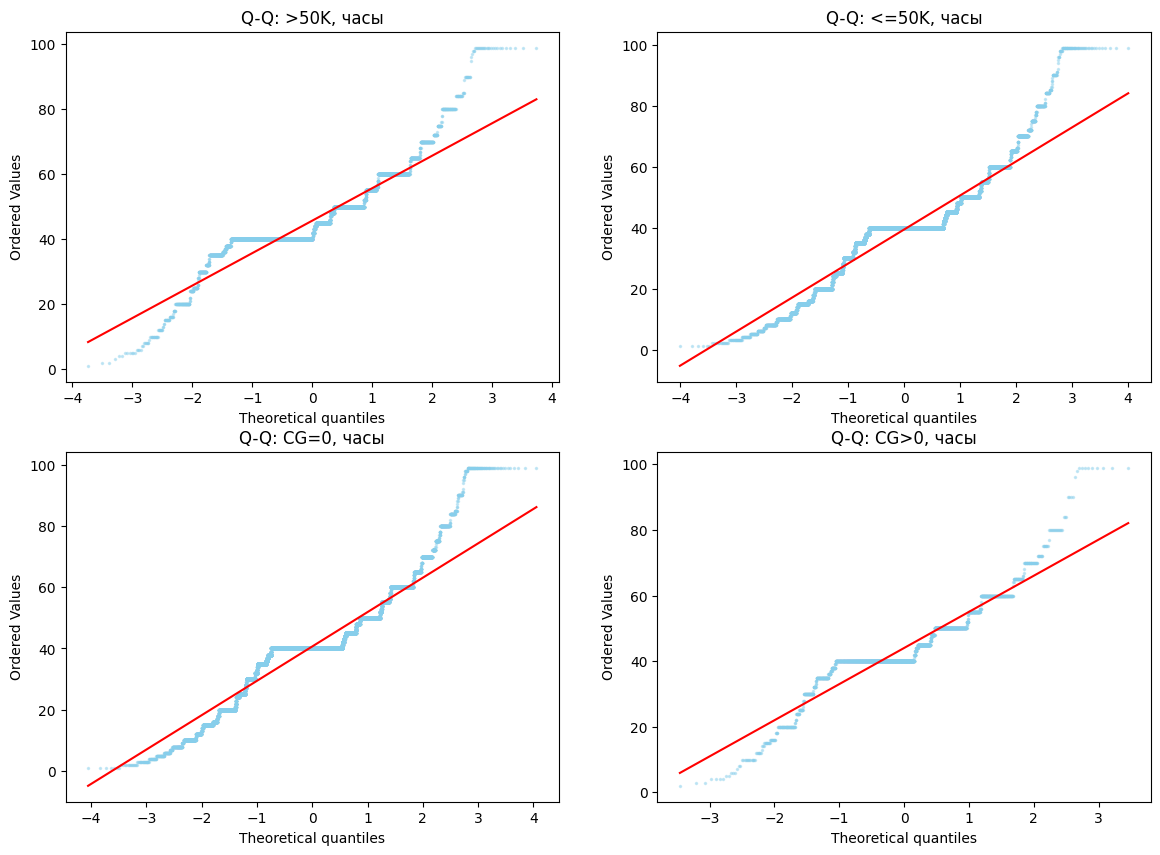

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, grp) in zip(axes.flat, check.items()):
    probplot(grp, dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {name}')
    ax.get_lines()[0].set(color='skyblue', markersize=1.5, alpha=0.4)
    ax.get_lines()[1].set(color='red')
plt.show()

**Вывод:** все группы отклоняются от нормального распределения (p < 0.05). Q-Q plots подтверждают: хвосты тяжелее нормальных, есть выраженная асимметрия. Это определяет выбор непараметрических критериев для непрерывных переменных. Для гипотез с пропорциями (H1, H3) нормальность не требуется — работает ЦПТ при больших n.

### 3.2 Однородность дисперсий — тест Левена

In [ ]:
p_h = levene(group_high, group_low)[1]
print(p_h)

p_cg = levene(cg0_hours, cg1_hours)[1]
print(p_cg)

p_edu = levene(*age_groups)[1]
print(p_edu)

6.021188644871823e-06
0.002236348623936614
7.60699692683641e-05


**Вывод:** Все тесты показали результат < 0.05, следовательно во всех случаях дисперсии статистически различаются

## Гипотезы

Проверять гипотезы будем на стандартном уровне значимости $\alpha=0.05$

In [ ]:
alpha = 0.05

### Гипотеза 1 — Гендерный разрыв сохраняется даже при высшем образовании

**Мотивация из EDA:** из раздела 2.3 видим, что мужчины значительно чаще зарабатывают >50K. Может ли это объясняться тем, что мужчины чаще получают высшее образование — или дело всё же в гендерном неравенстве?

- **$H_0$:** Среди людей с высшим образованием доля >50K одинакова у мужчин и женщин: $p_m = p_f$  
- **$H_1$:** Доля мужчин с >50K выше: $p_m > p_f$

**Z-тест для двух пропорций**  
Целевая переменная бинарна, группы независимы, при n > 1000 по ЦПТ Z-тест для пропорций подходит

In [ ]:
df_edu = df[df['education'].isin(['Bachelors','Masters','Prof-school','Doctorate'])]
m = df_edu[df_edu['sex'] == 'Male']
f = df_edu[df_edu['sex'] == 'Female']

n_m, n_f = len(m), len(f)
s_m = len(m[m['income'] == '>50K'])
s_f = len(f[f['income'] == '>50K'])
p_m, p_f = s_m / n_m, s_f / n_f

print('С высшим образованием:')
print(f'Мужчины: n={n_m}, доля >50K = {round(p_m, 2)} ({round(p_m*100, 1)}%)')
print(f'Женщины): n={n_f}, доля >50K = {round(p_f, 2)} ({round(p_f*100, 1)}%)')
print(f'Разность долей: {round(p_m - p_f, 4)}')

С высшим образованием:
Мужчины: n=5389, доля >50K = 0.58 (58.5%)
Женщины): n=2199, доля >50K = 0.26 (26.4%)
Разность долей: 0.3208


In [ ]:
p_m_all = len(df[(df['sex'] == 'Male') & (df['income'] == '>50K')]) / len(df[df['sex'] == 'Male'])
p_f_all = len(df[(df['sex'] == 'Female') & (df['income'] == '>50K')]) / len(df[df['sex'] == 'Female'])
print(f'\nРазрыв в полной выборке: {round(p_m_all - p_f_all, 4)}')
print(f'Разрыв среди людей с высшим: {round(p_m - p_f, 4)}')
print(f'Разность долей: {round(p_m_all - p_f_all, 4)}')


Разрыв в полной выборке: 0.2002
Разрыв среди людей с высшим: 0.3208
Разность долей: 0.2002


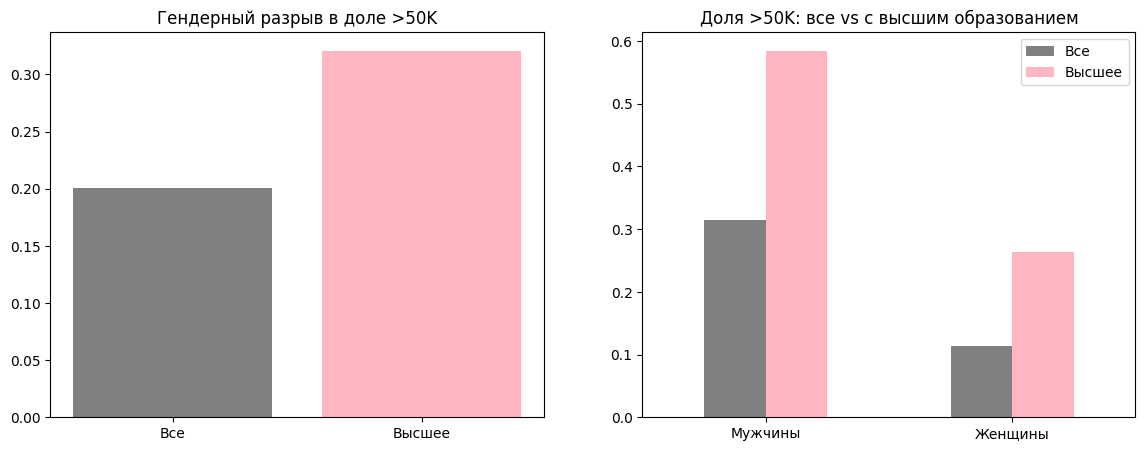

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Все', 'Высшее'], [p_m_all - p_f_all, p_m - p_f], color=['grey', 'lightpink'])
axes[0].set_title('Гендерный разрыв в доле >50K')

pd.DataFrame({
    'Все': [p_m_all, p_f_all],
    'Высшее': [p_m, p_f]
}, index=['Мужчины', 'Женщины']).plot(kind='bar', color=['grey', 'lightpink'], ax=axes[1], rot=0)
axes[1].set_title('Доля >50K: все vs с высшим образованием')

plt.show()

In [ ]:
z1, pz1 = proportions_ztest([s_m, s_f], [n_m, n_f], alternative='larger')
print(f'Z-статистика = {round(z1, 4)}')
print(f'p-value = {pz1:.2e}')

Z-статистика = 25.3563
p-value = 3.83e-142


**Вывод:**  
Z-тест отвергает H0: среди людей с высшим образованием мужчины значимо чаще зарабатывают >50K

Разрыв при контроле на образование сокращается, но не исчезает - высшее образование не выравнивает возможности

Гендер остаётся значимым предиктором дохода вне зависимости от уровня образования, что может указывать на структурные различия в занятости и типах должностей

### Гипотеза 2 — Семейный статус объясняет гендерный разрыв в доходах?

**Мотивация из EDA:** из раздела 2.5 видим, что люди в браке имеют доход выше, и среди мужчин доля состоящих в браке выше, чем у женщин. Тогда есть вероятность, что разница в доходе возникает не из-за пола, а из-за семейного статуса

- **$H_0$:** Внутри каждой группы семейного положения доля >50K одинакова у мужчин и женщин: $p_m = p_f$   
- **$H_1$:** Мужчины зарабатывают >50K чаще женщин независимо от семейного статуса: $p_m > p_f$

**Z-тест + Хи-квадрат**  
Проводим Z-тест отдельно для каждой из 7 групп семейного статуса. Поскольку выполняется 7 сравнений одновременно, используем поправку Бонферрони, чтобы избежать ошибок первого рода
Дополнительно применяем Хи-квадрат для проверки согласованности результатов

In [ ]:
alpha_bonf = alpha / df['marital_group'].nunique()
rows = []
for status in df['marital_group'].unique():
    sub = df[df['marital_group'] == status]
    m = sub[sub['sex'] == 'Male']
    f = sub[sub['sex'] == 'Female']
    n_m, n_f = len(m), len(f)
    s_m = len(m[m['income'] == '>50K'])
    s_f = len(f[f['income'] == '>50K'])
    p_m = s_m / n_m
    p_f = s_f / n_f

    p_z = proportions_ztest([s_m, s_f], [n_m, n_f], alternative='larger')[1]
    p_chi = chi2_contingency(pd.crosstab(sub['sex'], sub['income']))[1]

    ans_z = p_z < alpha_bonf
    ans_chi = p_chi < alpha_bonf

    rows.append({
        'статус': status,
        'мужчины': round(p_m, 3),
        'женщины': round(p_f, 3),
        'разрыв': round(p_m - p_f, 3),
        'p-value Z': round(p_z, 4),
        'p-value CHI': round(p_chi, 4),
        'значимо Z': '+' if ans_z else '-',
        'значимо CHI': '+' if ans_chi else '-',
        'согласованность': 'согласуются' if ans_z == ans_chi else 'расходятся'})

pd.DataFrame(rows)

,статус,мужчины,женщины,разрыв,p-value Z,p-value CHI,значимо Z,значимо CHI,согласованность
0,Never-married,0.057,0.038,0.019,0.0000,0.0000,+,+,согласуются
1,Married,0.448,0.427,0.021,0.0481,0.1015,-,-,согласуются
2,Divorced,0.165,0.069,0.096,0.0000,0.0000,+,+,согласуются
3,Separated,0.134,0.030,0.105,0.0000,0.0000,+,+,согласуются
4,Widowed,0.277,0.060,0.217,0.0000,0.0000,+,+,согласуются


**Вывод**  
При поправке Бонферрони тесты согласуются во всех группах — вывод не зависит от выбора метода.  
В большинстве групп гендерный разрыв статистически значим. Исключение — группа *Married*: замужние женщины и женатые мужчины имеют сопоставимый доход

### Гипотеза 3 — Самозанятые зарабатывают больше, чем наемные работники

**Мотивация из EDA:** в разделе 2.4 ярко видно, что Self-emp-inc гораздо чаще имеют высокий доход. Разрыв настолько большой, что хочется проверить: случайность это или устойчивая закономерность

- **$H_0$:** Доля людей с доходом >50K одинакова у самозанятых с собственным бизнесом и наёмных работников: $p_{self} = p_{priv}$  
- **$H_1$:** Самозанятые с собственным бизнесом зарабатывают >50K чаще: $p_{self} > p_{priv}$

**t-тест Уэлча для двух независимых выборок**  
Кодируем доход как бинарную переменную и сравниваем средние между двумя группами. n > 1000 в каждой группе — по ЦПТ распределение выборочных средних нормально, параметрический тест корректен. Используем вариант Уэлча, так как тест Левена показал неравенство дисперсий

In [ ]:
grp_self = (df[df['workclass'] == 'Self-emp-inc']['income'] == '>50K').astype(int)
grp_priv = (df[df['workclass'] == 'Private']['income'] == '>50K').astype(int)

print(f'Self-emp-inc: n={len(grp_self)}, среднее={round(grp_self.mean(), 4)}, std={round(grp_self.std(), 4)}')
print(f'Private: n={len(grp_priv)}, среднее={round(grp_priv.mean(), 4)}, std={round(grp_priv.std(), 4)}')

Self-emp-inc: n=1074, среднее=0.5587, std=0.4968
Private: n=22286, среднее=0.2188, std=0.4134


In [ ]:
pt3 = stats.ttest_ind(grp_self, grp_priv, equal_var=False, alternative='greater')[1]

f'p-value = {pt3:.2e}'

'p-value = 1.96e-90'

**Вывод:**  
Тест **отвергает** $H_0$. Самозанятые зарабатывают >50K значимо чаще, чем наемные работники.

### Гипотеза 4 — Возраст достижения высокого дохода зависит от уровня образования

**Мотивация из EDA:** в разделе 2.8 графики показали, что медианный возраст людей с доходом >50K отличается в зависимости от уровня образования — Doctorate заметно старше Bachelors. Хочется проверить, являются ли эти различия статистически значимыми

- **$H_0$:** Средний возраст достижения дохода >50K одинаков во всех группах образования  
- **$H_1$:** Хотя бы одна группа образования значимо отличается по среднему возрасту достижения >50K

**Welch ANOVA**  
Сравниваем непрерывную переменную (возраст) в 5 независимых группах (уровни образования). Нормальность нарушена (по Q-Q plots), но n > 200 в каждой группе —> по ЦПТ распределение нормально, параметрический тест корректен. Тест Левена показал неравенство дисперсий, используем Welch ANOVA вместо обычной ANOVA

In [ ]:
edu_5 = ['HS-grad','Some-college','Bachelors','Masters','Doctorate']
age_groups = [df[(df['income'] == '>50K') & (df['education'] == e)]['age'] for e in edu_5]

print('Описательная статистика возраста (только доход >50K):')
for e, grp in zip(edu_5, age_groups):
    print(f'{e}: n={len(grp)}, среднее={round(grp.mean(),1)}, std={round(grp.std(), 1)}')

Описательная статистика возраста (только доход >50K):
HS-grad: n=1617, среднее=44.7, std=10.3
Some-college: n=1336, среднее=43.9, std=10.3
Bachelors: n=2126, среднее=42.4, std=10.2
Masters: n=918, среднее=45.2, std=9.3
Doctorate: n=280, среднее=48.1, std=10.6


In [ ]:
welch = pg.welch_anova(dv='age', between='education', data=df_rich)

f'p-value = {welch['p_unc'][0]:.2e}'

'p-value = 6.49e-23'

**Вывод:**  
тест отвергает $H_0$ — средний возраст достижения >50K статистически значимо различается между уровнями образования.

### 8. Итоговые выводы

**H1** — высшее образование не стирает разницу в доходах между мужчинами и женщинами. Среди людей с дипломом мужчины всё равно зарабатывают >50K заметно чаще. Дело не только в образовании — есть что-то ещё...

**H2** — семейный статус влияет, но не объясняет всё. В большинстве групп мужчины зарабатывают больше вне зависимости от того, женаты они или нет. Единственное исключение — женатые/замужние: здесь разрыв исчезает. То есть брак как-то выравнивает ситуацию, но за его пределами женщины проигрывают :(

**H3** — владельцы собственного бизнеса зарабатывают >50K значительно чаще, чем обычные наёмные работники. Разница не случайная и ощутимая на практике

**H4** — твозраст, когда человек начинает хорошо зарабатывать, зависит от уровня образования. Люди с докторской степенью выходят на высокий доход позже всех — они дольше учатся. Бакалавры и магистры добираются до >50K раньше.